# SEM — Paper Reproduction Notebook

**Companion to:** *"Modeling Pragmatic Reasoning behind Social Meaning"*
(target journal: *Meaning*). This notebook reproduces **every data-driven result
reported in the manuscript** — all numbers, statistical effects, and figures —
for both case studies. It is intended as the reviewer/replication resource and
as the **single source of the paper's data figures**: running it regenerates the
figures saved under `figures/generated/`, which are then integrated into the
LaTeX manuscript.

**Scope.**
- Reproduces: §3.2 effects (LMM), §3.3 motivation analysis (t-tests, φ
  derivation), §3.4 predictions + robustness, and the Quantitative Evaluation
  (balanced fit, grid-search calibration, variant comparison).
- Generates figures: **Fig. 4** (Task 1 ratings), **Fig. 5** (Task 2
  frequencies), **Fig. 8** (model vs. empirical).
- **Figure 7** is a composite assembled in LaTeX (`figures/overviewTask2.tex`);
  here we emit its tables (p-values, mappings, φ matrices) separately.
- **Not** generated: conceptual diagrams are hand-drawn.

Run top-to-bottom. Cells are self-contained relative to the **Setup** cell.


## Setup

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['text.usetex'] = False   # set True for paper-quality fonts (needs LaTeX)
import matplotlib.pyplot as plt

# --- Locate repo root (works whether cwd is notebooks/ or the repo root) ---
def _find(rel):
    for base in ('..', '.', os.path.dirname(os.getcwd())):
        p = os.path.join(base, rel)
        if os.path.exists(p):
            return os.path.abspath(p)
    return os.path.abspath(rel)

REPO   = os.path.dirname(_find('sem'))
sys.path.insert(0, REPO)
DATA   = os.path.join(REPO, 'data', 'cs1_experiment', 'processed', 'experiment1.csv')
FIGDIR = os.path.join(REPO, 'figures', 'generated')
os.makedirs(FIGDIR, exist_ok=True)

from case_studies import cs1_imprecision as CS1
from sem.impact_derivation import (
    derive_trivalent_matrix, CS1_SEM_MAPPING, CS1_SEM_ATTR_MAPPING,
)
from sem.plotting import plot_cs1

try:
    import statsmodels.formula.api as smf
    HAVE_SM = True
except Exception as e:
    HAVE_SM = False
    print('WARNING: statsmodels unavailable -', type(e).__name__, str(e).splitlines()[0])
    print('Install:  pip install -U "statsmodels>=0.14.4" --break-system-packages')

def savefig(fig, name):
    # Save a figure to figures/generated/ as both PDF (for LaTeX) and PNG.
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(FIGDIR, f'{name}.{ext}'), bbox_inches='tight', dpi=150)
    print(f'  saved: figures/generated/{name}.pdf (+ .png)')

print('Repo root :', REPO)
print('Data file :', 'OK' if os.path.exists(DATA) else 'MISSING', '-', DATA)
print('Figure out:', FIGDIR)
print('statsmodels:', 'OK' if HAVE_SM else 'MISSING')

Repo root : /Users/roland/GitHub/sem-pragmatics
Data file : OK - /Users/roland/GitHub/sem-pragmatics/data/cs1_experiment/processed/experiment1.csv
Figure out: /Users/roland/GitHub/sem-pragmatics/figures/generated
statsmodels: OK


# Section 3 — Case Study 1: Numerical (Im)Precision

## 3.2 — Experimental Results

> *"For competent and pedantic, a significant main effect of form was found, with
> precise rated higher (p < .001 for both). For competent and likeable, a
> significant interaction of context and form was found … (p < .001 for both)."*

Linear mixed effects models (`attribute ~ form * context`, random intercept for
scenario, sum coding) on Experiment 1, matching the paper's `lmerTest` analysis.

In [2]:
assert HAVE_SM, 'statsmodels required for the §3.2 mixed models'
df = pd.read_csv(DATA)
df['form_c'] = df['form'].map({'precise': 1, 'approx': -1})
df['ctx_c']  = df['context'].map({'highPr': 1, 'lowPr': -1})

res = {}
for a in ['competent', 'likeable', 'pedantic']:
    m = smf.mixedlm(f'{a} ~ form_c * ctx_c', df, groups=df['scenario']).fit(reml=False)
    res[a] = dict(fb=m.params['form_c'], fp=m.pvalues['form_c'],
                  ib=m.params['form_c:ctx_c'], ip=m.pvalues['form_c:ctx_c'])

def ok(b): return 'OK' if b else 'MISMATCH'
print('Effect (Experiment 1, LMM)                              b        p      verdict')
print('-' * 72)
r = res['competent']
print(f"1 form->competent (precise>approx, p<.001)        {r['fb']:+6.3f}  {r['fp']:.2e}   {ok(r['fb']>0 and r['fp']<.001)}")
r = res['pedantic']
print(f"2 form->pedantic  (precise>approx, p<.001)        {r['fb']:+6.3f}  {r['fp']:.2e}   {ok(r['fb']>0 and r['fp']<.001)}")
r = res['likeable']
print(f"  form->likeable  (no sig. main effect)           {r['fb']:+6.3f}  {r['fp']:.2e}   {ok(r['fp']>=.05)}")
r = res['competent']
print(f"3 form x context on competent (p<.001)            {r['ib']:+6.3f}  {r['ip']:.2e}   {ok(r['ip']<.001)}")
r = res['likeable']
print(f"4 form x context on likeable  (p<.001)            {r['ib']:+6.3f}  {r['ip']:.2e}   {ok(r['ip']<.001)}")

Effect (Experiment 1, LMM)                              b        p      verdict
------------------------------------------------------------------------
1 form->competent (precise>approx, p<.001)        +0.434  1.02e-12   OK
2 form->pedantic  (precise>approx, p<.001)        +0.442  8.96e-07   OK
  form->likeable  (no sig. main effect)           +0.074  2.37e-01   OK
3 form x context on competent (p<.001)            +0.276  5.82e-06   OK
4 form x context on likeable  (p<.001)            +0.212  7.22e-04   OK


### Figure 4 — Task 1 rating results (empirical)

Mean ratings (1–7) with standard deviations, by form × context, for the three
SEM attributes. Corresponds to manuscript Figure 4 (`threePlotsEmp2png.png`).

  saved: figures/generated/fig4_cs1_empirical_task1.pdf (+ .png)


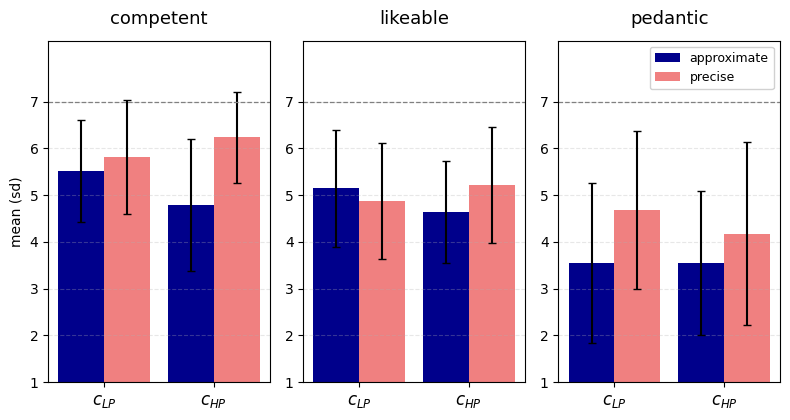

In [3]:
df = pd.read_csv(DATA)
attrs = ['competent', 'likeable', 'pedantic']
forms = ['approx', 'precise']
ctxs  = ['lowPr', 'highPr']
ctx_lbl = ['$c_{LP}$', '$c_{HP}$']
col = {'approx': 'darkblue', 'precise': 'lightcoral'}

# Headroom above the 7 ceiling so SD whiskers that exceed 7 are not clipped.
upper = max(df[(df.form == f) & (df.context == c)][a].mean()
            + df[(df.form == f) & (df.context == c)][a].std()
            for a in attrs for f in forms for c in ctxs)
ytop = max(8.0, np.ceil(upper) + 0.3)

fig, axes = plt.subplots(1, 3, figsize=(8.0, 4.3))   # taller aspect for print readability
for ax, a in zip(axes, attrs):
    for j, f in enumerate(forms):
        means = [df[(df.form == f) & (df.context == c)][a].mean() for c in ctxs]
        sds   = [df[(df.form == f) & (df.context == c)][a].std()  for c in ctxs]
        x = np.arange(len(ctxs)) + (j - 0.5) * 0.42
        ax.bar(x, means, 0.42, yerr=sds, capsize=3, color=col[f],
               label={'approx': 'approximate', 'precise': 'precise'}[f])
    ax.set_title(a, fontsize=13, pad=12)                    # panel label (kept)
    ax.set_xticks(range(len(ctxs))); ax.set_xticklabels(ctx_lbl, fontsize=12)
    ax.set_ylim(1, ytop); ax.set_yticks(range(1, 8))
    ax.axhline(7, color='gray', lw=0.9, ls='--')           # rating-scale ceiling at 7
    ax.grid(axis='y', ls='--', alpha=0.3)
axes[0].set_ylabel('mean (sd)')
# Legend sits in the empty band above 7, clear of the SD whiskers.
axes[-1].legend(fontsize=9, loc='upper right', framealpha=0.9)
fig.tight_layout()
savefig(fig, 'fig4_cs1_empirical_task1')
plt.show()

### Figure 5 — Task 2 motivation class frequencies

The 10 most frequently mentioned motivation classes, stacked by form
(approximate = blue, precise = red). Corresponds to manuscript Figure 5
(`freqT2x.png`).

  saved: figures/generated/fig5_cs1_task2_frequencies.pdf (+ .png)


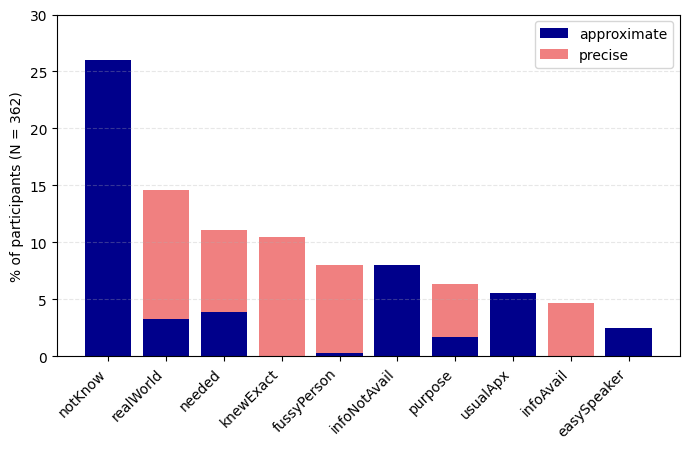


Top-10 classes (% of N=362;  approx / precise / total):
  notKnow         26.0% /   0.0% /  26.0%
  realWorld        3.3% /  11.3% /  14.6%
  needed           3.9% /   7.2% /  11.0%
  knewExact        0.0% /  10.5% /  10.5%
  fussyPerson      0.3% /   7.7% /   8.0%
  infoNotAvail     8.0% /   0.0% /   8.0%
  purpose          1.7% /   4.7% /   6.4%
  usualApx         5.5% /   0.0% /   5.5%
  infoAvail        0.0% /   4.7% /   4.7%
  easySpeaker      2.5% /   0.0% /   2.5%


In [4]:
df = pd.read_csv(DATA)
N = len(df)
t2 = [c for c in df.columns
      if c.startswith('t2_') and c not in ('t2_response', 't2_other')
      and pd.api.types.is_numeric_dtype(df[c])]
totals = df[t2].sum().sort_values(ascending=False)
top = totals.head(10).index.tolist()
labels  = [c[3:] for c in top]
approx  = [int(df[df.form == 'approx'][c].sum())  for c in top]
precise = [int(df[df.form == 'precise'][c].sum()) for c in top]
# express as percentage of the total number of participants
approx_pct  = [100 * a_ / N for a_ in approx]
precise_pct = [100 * p_ / N for p_ in precise]
ymax = int(np.ceil(max(a_ + p_ for a_, p_ in zip(approx_pct, precise_pct)) / 5.0) * 5)

x = np.arange(len(top))
fig, ax = plt.subplots(figsize=(7.0, 4.6))            # taller aspect for print readability
ax.bar(x, approx_pct, color='darkblue', label='approximate')
ax.bar(x, precise_pct, bottom=approx_pct, color='lightcoral', label='precise')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel(f'% of participants (N = {N})')
ax.set_yticks(np.arange(0, ymax + 1, 5)); ax.set_ylim(0, ymax)
ax.grid(axis='y', ls='--', alpha=0.3)
ax.legend()
fig.tight_layout()
savefig(fig, 'fig5_cs1_task2_frequencies')
plt.show()
print(f'\nTop-10 classes (% of N={N};  approx / precise / total):')
for l, a_, p_ in zip(labels, approx_pct, precise_pct):
    print(f'  {l:14s} {a_:5.1f}% / {p_:5.1f}% / {a_+p_:5.1f}%')

### Table for Figure 7(b) — motivation × attribute t-tests

Per the revised analysis: independent-samples *t*-tests (checked vs. not-checked),
Experiment 1, significance at **p < .01**. These p-values populate panel (b) of
the composite Figure 7 (assembled in `figures/overviewTask2.tex`).

In [5]:
from scipy.stats import ttest_ind
df = pd.read_csv(DATA)
ATTRS = ['competent', 'likeable', 'pedantic']

n_sig = 0
print(f"{'SEM var':7s} {'proxy':13s} " + ' '.join(f'{a:>14s}' for a in ATTRS))
print('-' * 64)
for var, proxies in CS1_SEM_MAPPING.items():
    for p in proxies:
        c = f't2_{p}'
        g1, g0 = df[df[c] == 1], df[df[c] == 0]
        cells_ = []
        for a in ATTRS:
            x1, x0 = g1[a].dropna(), g0[a].dropna()
            _, pv = ttest_ind(x1, x0, equal_var=True)
            sgn = '+' if x1.mean() > x0.mean() else '-'
            star = '**' if pv < .01 else ('*' if pv < .05 else '')
            if pv < .01:
                n_sig += 1
            cells_.append(f'{pv:.3f}{sgn}{star:2s}')
        print(f'{var:7s} {p:13s} ' + ' '.join(f'{c_:>14s}' for c_ in cells_))
print(f'\nSignificant effects at p<.01: {n_sig} / 30  (manuscript reports 7/30)')

SEM var proxy              competent       likeable       pedantic
----------------------------------------------------------------
k_p     knewExact           0.000+**       0.480+         0.028+* 
k_p     infoAvail           0.116+         0.185-         0.015+* 
k_np    notKnow             0.000-**       0.189-         0.000-**
k_np    infoNotAvail        0.851+         0.507-         0.096-  
m_max   fussyPerson         0.033+*        0.016-*        0.001+**
m_sit   needed              0.010+**       0.331+         0.131-  
m_sit   purpose             0.034+*        0.000+**       0.252+  
m_sit   realWorld           0.098+         0.365+         0.857+  
m_min   easySpeaker         0.003-**       0.062-         0.199-  
m_min   usualApx            0.129-         0.933-         0.106-  

Significant effects at p<.01: 7 / 30  (manuscript reports 7/30)


## 3.3 — Fitting the Model

Tables for Figure 7(c) (mappings) and 7(d) (trivalent functions φ_K, φ_M).
The φ matrices are re-derived live from the data (t-tests, p<.01, majority vote)
and checked against the committed `IMPACT_K`/`IMPACT_M`.

In [6]:
# Figure 7(c) — proxy -> SEM variable mapping
print('Figure 7(c) — mappings (proxy -> SEM variable):')
for var, proxies in CS1_SEM_MAPPING.items():
    print(f'  {var:6s} <- {proxies}')

# Figure 7(d) — trivalent functions, derived vs committed
derived = derive_trivalent_matrix(DATA, CS1_SEM_MAPPING, CS1_SEM_ATTR_MAPPING, alpha=0.01)
current = {**CS1.IMPACT_K, **CS1.IMPACT_M}
cols = ['a_comp', 'a_like', 'a_ped']
print('\nFigure 7(d) — phi_K / phi_M  (committed values; ! = differs from live derivation):')
print(f"{'':7s}" + ''.join(f'{c:>9s}' for c in cols))
match = True
for var in ['k_p', 'k_np', 'm_max', 'm_sit', 'm_min']:
    row = []
    for c in cols:
        cv, dv = current[var][c], derived[var][c]
        flag = '' if cv == dv else '!'
        match &= (cv == dv)
        row.append(f'{cv:+d}{flag}')
    print(f'{var:7s}' + ''.join(f'{r:>9s}' for r in row))
print('\nCommitted IMPACT matrices match live t-test derivation:', match)

Figure 7(c) — mappings (proxy -> SEM variable):
  k_p    <- ['knewExact', 'infoAvail']
  k_np   <- ['notKnow', 'infoNotAvail']
  m_max  <- ['fussyPerson']
  m_sit  <- ['needed', 'purpose', 'realWorld']
  m_min  <- ['easySpeaker', 'usualApx']



Figure 7(d) — phi_K / phi_M  (committed values; ! = differs from live derivation):
          a_comp   a_like    a_ped
k_p           +1       +0       +0
k_np          -1       +0       -1
m_max         +0       +0       +1
m_sit         +1       +1       +0
m_min         -1       +0       +0

Committed IMPACT matrices match live t-test derivation: True


## 3.4 — Model Predictions

> *"The balanced model correctly predicted all four effects … SEM correctly
> predicted all four effects for 99.87% of combinations; for the remaining 0.13%
> it correctly predicted three out of four."*

In [7]:
sc = CS1.build_scenario(omega=0.5)      # balanced: uniform priors
scores = sc.evaluate_all()

# Prediction table
print('Balanced model (omega=0.5, uniform priors) — E_L(a | v, c):')
combos = [(v, c) for v in CS1.UTTERANCES for c in CS1.CONTEXTS]
print(f"{'attr':8s}" + ''.join(f'{v+"|"+c:>13s}' for v, c in combos))
for a in CS1.ATTRIBUTES:
    print(f'{a:8s}' + ''.join(f'{scores[a][v][c]:+12.3f} ' for v, c in combos))

# Four effects
eff = CS1.target_effects(scores)
labels = ['1 precise>approx competent', '2 precise>approx pedantic',
          '3 competent gap larger in c_HP', '4 likeable gap larger in c_HP']
print('\nTarget effects:')
for l, e in zip(labels, eff):
    print(f'  {"OK " if e else "XX "} {l}')
print('All four predicted:', all(eff))

Balanced model (omega=0.5, uniform priors) — E_L(a | v, c):
attr       v_prc|c_HP   v_prc|c_LP   v_apx|c_HP   v_apx|c_LP
a_comp        +0.750       +0.500       -0.250       +0.000 
a_like        +0.250       +0.000       +0.083       +0.208 
a_ped         +0.250       +0.500       -0.167       -0.167 

Target effects:
  OK  1 precise>approx competent
  OK  2 precise>approx pedantic
  OK  3 competent gap larger in c_HP
  OK  4 likeable gap larger in c_HP
All four predicted: True


### Figure 8 — Model predictions vs. empirical

Top row: model evaluation scores $E_L \in [-1, 1]$. Bottom row: empirical Task 1
means linearly rescaled from the 1–7 scale to $[-1, 1]$ via $(x-4)/3$. Bars rise
from the **scale floor ($-1$, the lowest evaluation)**; note that **0 is a
median/intermediate score, not a neutral point** — the same holds for the model.
Corresponds to manuscript Figure 8 (`three_plots4.pdf`).

  saved: figures/generated/fig8_cs1_model_vs_empirical.pdf (+ .png)


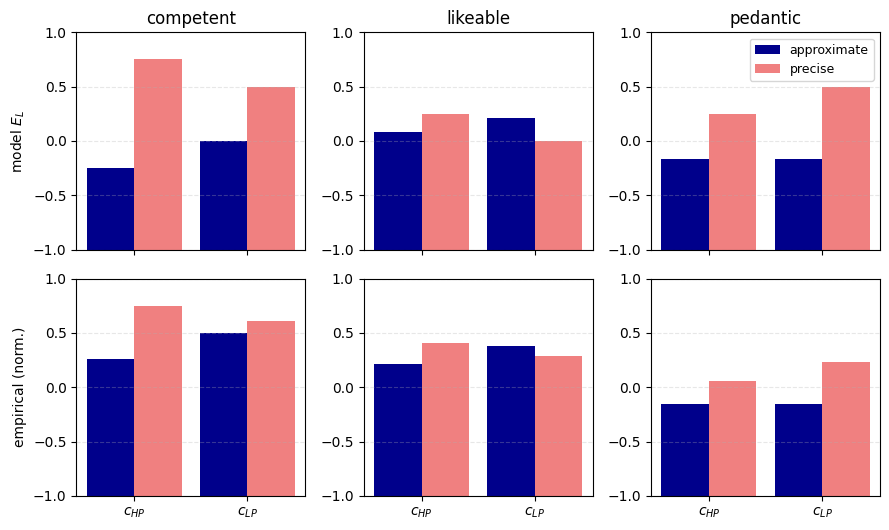

In [8]:
df = pd.read_csv(DATA)
attrs   = ['a_comp', 'a_like', 'a_ped']
raw     = {'a_comp': 'competent', 'a_like': 'likeable', 'a_ped': 'pedantic'}
forms   = [('approx', 'v_apx'), ('precise', 'v_prc')]
ctxs    = [('highPr', 'c_HP'), ('lowPr', 'c_LP')]
col     = {'approx': 'darkblue', 'precise': 'lightcoral'}
titles  = {'a_comp': 'competent', 'a_like': 'likeable', 'a_ped': 'pedantic'}
FLOOR   = -1.0   # bars start at the scale floor (lowest evaluation), not at 0

def _bars(ax, xs, vals, color, label=None):
    # draw bars rising from FLOOR up to each value
    ax.bar(xs, [v - FLOOR for v in vals], 0.42, bottom=FLOOR, color=color, label=label)

fig, axes = plt.subplots(2, 3, figsize=(9, 5.4), sharex=True)
for k, a in enumerate(attrs):
    # Row 0: model E_L
    axm = axes[0, k]
    for j, (f, vf) in enumerate(forms):
        vals = [scores[a][vf][cm] for _, cm in ctxs]
        x = np.arange(2) + (j - 0.5) * 0.42
        _bars(axm, x, vals, col[f], {'approx': 'approximate', 'precise': 'precise'}[f])
    axm.set_title(titles[a], fontsize=12)
    axm.set_ylim(FLOOR, 1.0); axm.set_yticks([-1, -0.5, 0, 0.5, 1])
    axm.grid(axis='y', ls='--', alpha=0.3)
    # Row 1: empirical, normalized to [-1, 1] via (x-4)/3
    axe = axes[1, k]
    for j, (f, vf) in enumerate(forms):
        vals = [(df[(df.form == f) & (df.context == cd)][raw[a]].mean() - 4) / 3
                for cd, _ in ctxs]
        x = np.arange(2) + (j - 0.5) * 0.42
        _bars(axe, x, vals, col[f])
    axe.set_ylim(FLOOR, 1.0); axe.set_yticks([-1, -0.5, 0, 0.5, 1])
    axe.grid(axis='y', ls='--', alpha=0.3)
    axe.set_xticks(range(2)); axe.set_xticklabels(['$c_{HP}$', '$c_{LP}$'])
axes[0, 0].set_ylabel('model $E_L$')
axes[1, 0].set_ylabel('empirical (norm.)')
axes[0, 2].legend(fontsize=9, loc='upper right')
fig.tight_layout()
savefig(fig, 'fig8_cs1_model_vs_empirical')
plt.show()

### Robustness (CS1)

Exhaustive grid sweep over ω and the priors. **The paper uses step = 0.02**
(~2.6M combinations), of which **99.87%** predict all four effects and 0.13%
predict three of four. Here we default to **step = 0.1** so the cell runs in
seconds; set `STEP = 0.02` below to reproduce the paper's exact figure (takes a
few minutes).

In [9]:
STEP = 0.1   # paper uses 0.02 -> 99.87% all-four; 0.1 is much faster. Set to 0.02 to reproduce exactly.

rob = sc.robustness_test(effects_fn=CS1.target_effects, step=STEP)
rate = 100 * rob['rate_all']
print(f"grid step           : {STEP}   (paper: 0.02)")
print(f"combinations tested : {rob['total']:,}")
print(f"all 4 effects hold  : {rob['all_correct']:,}  ({rate:.2f}%)")
for i, c in enumerate(rob['per_effect'], 1):
    print(f"  effect {i}           : {100*c/rob['total']:.2f}%")
print(f"\nManuscript (step 0.02): 99.87% all-four / 0.13% three-of-four.")
print(f"At step {STEP}: {rate:.2f}% all-four (coarser grid; set STEP=0.02 above to match the paper exactly).")

grid step           : 0.1   (paper: 0.02)
combinations tested : 2,916
all 4 effects hold  : 2,916  (100.00%)
  effect 1           : 100.00%
  effect 2           : 100.00%
  effect 3           : 100.00%
  effect 4           : 100.00%

Manuscript (step 0.02): 99.87% all-four / 0.13% three-of-four.
At step 0.1: 100.00% all-four (coarser grid; set STEP=0.02 above to match the paper exactly).


# Section 4 — Quantitative Evaluation

Beyond reproducing the *direction* of the four effects, the manuscript quantifies
*how well* the balanced model fits Experiment 1 with a metric suite (Mühlenbernd
2026), and compares SEM against ablated variants. This reproduces the manuscript
section **Quantitative Evaluation** (Metric Framework, Balanced Model Fit, Model
Variant Comparison).

**Metric framework.** DAS (Directional Agreement Score), ISS (Interaction
Sensitivity Score), ESR (Effect Size Ratio) and CDS (Calibration Deviation Score)
are computed over the **four statistically significant effects only** (significant
main effects: $a_{comp}$, $a_{ped}$; significant interactions: $a_{comp}$,
$a_{like}$). RMSE is computed cell-by-cell over all 12 condition means. Testing
directional agreement or magnitude calibration on the non-significant effects
would be scoring noise rather than signal.

## Balanced Model Fit

> *"the balanced model achieves perfect directional agreement on all significant
> effects: DAS = 1.00 and ISS = 1.00 … the model overshoots effect magnitudes on
> main effects (ESR ≈ 2×)."*

Reproduces the manuscript's **Balanced Model Fit** table (ω = 0.5, flat priors,
vs. Experiment 1, N = 362). `scores` is the balanced-model E_L from §3.4.

In [10]:
from sem import fit

MEANS = os.path.join(REPO, 'data', 'cs1_experiment', 'processed', 'empirical_means_cs1.json')

# scores = balanced model E_L from the §3.4 cell (omega=0.5, uniform priors)
res = fit.evaluate(scores, MEANS)

print('Balanced model fit (omega=0.5, flat priors) vs. Experiment 1 (N=362)')
print('DAS / ISS / ESR / CDS over the 4 significant effects; RMSE over all 12 cells.\n')
print(f"  RMSE                       : {res['rmse']:.2f}")
print(f"  DAS  (sig. main effects)   : {res['das']:.2f}")
print(f"  ISS  (sig. interactions)   : {res['iss']:.2f}")
print(f"  ESR main  a_comp / a_ped   : {res['esr_main']['a_comp']:.2f} / {res['esr_main']['a_ped']:.2f}")
print(f"  ESR inter a_comp / a_like  : {res['esr_interaction']['a_comp']:.2f} / {res['esr_interaction']['a_like']:.2f}")
print(f"  CDS main / inter / overall : {res['cds_main']:.2f} / {res['cds_interaction']:.2f} / {res['cds']:.2f}")
print('\nManuscript table: RMSE 0.26 · DAS 1.00 · ISS 1.00 · ESR 2.55/1.83 (main),')
print('  1.32/1.31 (inter) · CDS 1.19/0.31/0.75.')

Balanced model fit (omega=0.5, flat priors) vs. Experiment 1 (N=362)
DAS / ISS / ESR / CDS over the 4 significant effects; RMSE over all 12 cells.

  RMSE                       : 0.26
  DAS  (sig. main effects)   : 1.00
  ISS  (sig. interactions)   : 1.00
  ESR main  a_comp / a_ped   : 2.55 / 1.83
  ESR inter a_comp / a_like  : 1.32 / 1.31
  CDS main / inter / overall : 1.19 / 0.31 / 0.75

Manuscript table: RMSE 0.26 · DAS 1.00 · ISS 1.00 · ESR 2.55/1.83 (main),
  1.32/1.31 (inter) · CDS 1.19/0.31/0.75.


## Grid-search calibration (post-hoc)

> *"A grid search over the free parameter space identifies a setting (ω = 0.7,
> P(k_p) = 0.9, P(m_max) = 0.5, P(m_sit) = 0.3, P(m_min) = 0.2) that achieves
> near-perfect calibration (CDS = 0.056 … RMSE = 0.165), while preserving
> ISS = 1.00."*

We scan a coarse grid (step 0.1) over ω, P(k_p) and the motivation-prior simplex,
keeping the setting that **minimizes CDS subject to ISS = 1.00** (structure must
hold). This is an **in-sample, post-hoc upper bound** on fit — the parameters are
tuned to the same 12 cells the φ functions were derived from — not a validated
generalization.

In [11]:
import numpy as np

grid_o  = [round(0.5 + 0.1 * i, 2) for i in range(5)]   # 0.5 .. 0.9
grid_kp = [round(0.5 + 0.1 * i, 2) for i in range(5)]   # 0.5 .. 0.9
steps   = [round(0.1 * i, 1) for i in range(1, 9)]      # 0.1 .. 0.8
m_simplex = [(a, b, round(1 - a - b, 2)) for a in steps for b in steps
             if round(1 - a - b, 2) >= 0.1 - 1e-9]      # P(m) on the simplex, each >= 0.1

best = None
for o in grid_o:
    for kp in grid_kp:
        for mmax, msit, mmin in m_simplex:
            sc_g = CS1.build_scenario(
                omega=o, priors_K={'k_p': kp, 'k_np': round(1 - kp, 2)},
                priors_M={'m_max': mmax, 'm_sit': msit, 'm_min': mmin})
            r = fit.evaluate(sc_g.evaluate_all(), MEANS)
            if r['iss'] == 1.0 and (best is None or r['cds'] < best['cds']):
                best = {**r, 'omega': o, 'kp': kp, 'm': (mmax, msit, mmin)}

n_grid = len(grid_o) * len(grid_kp) * len(m_simplex)
print(f'Grid search ({n_grid} settings, step 0.1) — best calibration with ISS = 1.00:')
print(f"  omega={best['omega']}, P(k_p)={best['kp']}, P(m)={best['m']} (max/sit/min)")
print(f"  CDS={best['cds']:.3f}  RMSE={best['rmse']:.3f}  ISS={best['iss']:.2f}")
print(f"  ESR: {best['esr_main']['a_comp']:.2f}, {best['esr_main']['a_ped']:.2f}, "
      f"{best['esr_interaction']['a_comp']:.2f}, {best['esr_interaction']['a_like']:.2f}")
print('\nManuscript optimum: omega=0.7, P(k_p)=0.9, P(m)=0.5/0.3/0.2')
print('  -> CDS=0.056, RMSE=0.165, ESR 1.03/1.01/1.15/0.96, ISS=1.00.')

Grid search (900 settings, step 0.1) — best calibration with ISS = 1.00:
  omega=0.7, P(k_p)=0.9, P(m)=(0.5, 0.3, 0.2) (max/sit/min)
  CDS=0.056  RMSE=0.165  ISS=1.00
  ESR: 1.03, 1.01, 1.15, 0.96

Manuscript optimum: omega=0.7, P(k_p)=0.9, P(m)=0.5/0.3/0.2
  -> CDS=0.056, RMSE=0.165, ESR 1.03/1.01/1.15/0.96, ISS=1.00.


## Model Variant Comparison

> *"ISS … collapses to ≈0 for the two variants that remove either context
> sensitivity or knowledge-state inference, showing that both components are
> necessary for predicting the interaction structure of the empirical effects."*

Four SEM variants (full, context-blind, knowledge-only, motivation-only) are each
evaluated over sampled parameter draws (mean ± SD), reproducing the manuscript's
**Model Variant Comparison** table. `N_SAMPLES` defaults to a small value so the
cell runs quickly; **the paper uses 100** — set `N_SAMPLES = 100` to reproduce the
table values exactly (the seed is fixed, so 100 is deterministic).

In [12]:
from sem.comparison import compare_all_variants, print_comparison_table

N_SAMPLES = 25   # paper uses 100; lower = faster. Set to 100 to reproduce the table exactly.

comparison = compare_all_variants(MEANS, n_samples=N_SAMPLES, seed=42)
print_comparison_table(comparison)
print(f'\n(n={N_SAMPLES} samples/variant; paper uses 100. Set N_SAMPLES=100 above to match exactly.)')
print('Key result — ISS: ~0 for the variants that drop context-sensitive motivation')
print('(context-blind, knowledge-only) and 1.00 for those that keep it (full,')
print('motivation-only); the interaction structure needs both components.')

=== SEM Variant Comparison ===

Metric          SEM-full        Context-blind   Know-only       Motiv-only      
────────────────────────────────────────────────────────────────────────────────
DAS             1.00 ± 0.00     1.00 ± 0.00     1.00 ± 0.00     1.00 ± 0.00     
ISS             1.00 ± 0.00     0.00 ± 0.00     0.06 ± 0.16     1.00 ± 0.00     
Spearman ρ      0.58 ± 0.21     0.24 ± 0.29     0.77 ± 0.09     -0.06 ± 0.27    
RMSE            0.32 ± 0.13     0.41 ± 0.09     0.37 ± 0.13     0.48 ± 0.07     
CCC             0.55 ± 0.24     0.26 ± 0.20     0.61 ± 0.13     0.02 ± 0.25     
CDS (main)      1.34 ± 0.88     1.62 ± 0.73     1.52 ± 1.20     0.91 ± 0.49     
CDS (inter)     0.87 ± 0.76     1.00 ± 0.00     1.00 ± 0.00     1.99 ± 1.41     
CDS (overall)   1.10 ± 0.45     1.31 ± 0.37     1.26 ± 0.60     1.45 ± 0.71     

ESR main effects (significant only):
  a_comp        2.78 ± 1.32     3.10 ± 1.09     3.09 ± 1.90     1.62 ± 0.94     
  a_ped         1.87 ± 0.52     2.13 ± 

## Threshold robustness

> *"The φ functions are derived at p < .01. … with φ derived at p < .05 … worsens
> the full model on every calibration metric … Tightening to p < .001 slightly
> improves CDS … but degrades interaction coverage (ISS 1.00 → 0.57) because the
> borderline m_sit–a_comp cell is dropped. The p < .01 threshold is the only one
> that maintains full interaction coverage while achieving competitive
> calibration."*

We re-derive $\phi_K$ and $\phi_M$ from the Experiment 1 data at each significance
threshold and re-run the **full-model** comparison. This justifies the committed
**p < .01**: a looser threshold (p < .05) adds φ cells and hurts calibration; a
tighter one (p < .001) drops the borderline $m_{sit}$–$a_{comp}$ cell, so the
model loses one of the two significant interactions (ISS falls below 1.00).

In [13]:
from sem.comparison import evaluate_variant, summarize_results

N_SAMPLES_THR = 100   # only the 'full' variant x 3 thresholds -> fast & deterministic (seed 42)
COLS = ['a_comp', 'a_like', 'a_ped']

def _nonzero_cells(matrix):
    return sum(1 for row in matrix.values() for c in COLS if row[c] != 0)

# Preserve the committed (p<.01) matrices and restore them afterwards, so re-running
# later cells is unaffected by the monkeypatching below.
_orig_K, _orig_M = CS1.IMPACT_K, CS1.IMPACT_M
note = {0.05:  'adds phi cells -> worse calibration',
        0.01:  'committed: best trade-off',
        0.001: 'drops m_sit-a_comp -> loses an interaction'}

print('Full-model fit vs. the significance threshold used to derive phi_K / phi_M:\n')
print(f"{'threshold':>10} {'phi cells':>10} {'ISS':>7} {'CDS':>7} {'RMSE':>7}   note")
for alpha in [0.05, 0.01, 0.001]:
    m = derive_trivalent_matrix(DATA, CS1_SEM_MAPPING, CS1_SEM_ATTR_MAPPING, alpha)
    CS1.IMPACT_K = {k: m[k] for k in ('k_p', 'k_np')}
    CS1.IMPACT_M = {k: m[k] for k in ('m_max', 'm_sit', 'm_min')}
    s = summarize_results(evaluate_variant('full', MEANS, n_samples=N_SAMPLES_THR, seed=42))
    print(f"{'p<' + format(alpha, 'g'):>10} {_nonzero_cells(m):>10} "
          f"{s['iss']['mean']:>7.2f} {s['cds']['mean']:>7.2f} {s['rmse']['mean']:>7.2f}   {note[alpha]}")

CS1.IMPACT_K, CS1.IMPACT_M = _orig_K, _orig_M   # restore committed p<.01 matrices
print('\n(committed p<.01 matrices restored.)')
print('Manuscript: p<.05 -> CDS 1.45, RMSE 0.51 (ISS unchanged); p<.001 -> CDS 0.89, ISS 0.57.')
print('Only p<.01 keeps ISS = 1.00 with competitive calibration -> the committed threshold.')

Full-model fit vs. the significance threshold used to derive phi_K / phi_M:

 threshold  phi cells     ISS     CDS    RMSE   note


    p<0.05         10    1.00    1.45    0.51   adds phi cells -> worse calibration


    p<0.01          7    1.00    0.94    0.30   committed: best trade-off


   p<0.001          5    0.57    0.89    0.29   drops m_sit-a_comp -> loses an interaction

(committed p<.01 matrices restored.)
Manuscript: p<.05 -> CDS 1.45, RMSE 0.51 (ISS unchanged); p<.001 -> CDS 0.89, ISS 0.57.
Only p<.01 keeps ISS = 1.00 with competitive calibration -> the committed threshold.


## Generated figures → manuscript

| Notebook output (`figures/generated/`) | Manuscript figure | LaTeX file currently used |
|---|---|---|
| `fig4_cs1_empirical_task1.pdf` | **Figure 4** | `figures/threePlotsEmp2png.png` |
| `fig5_cs1_task2_frequencies.pdf` | **Figure 5** | `figures/freqT2x.png` |
| *(tables only — composed in LaTeX)* | **Figure 7** | `figures/overviewTask2.tex` → `overviewTask2.pdf` |
| `fig8_cs1_model_vs_empirical.pdf` | **Figure 8** | `figures/three_plots4.pdf` |

The Quantitative Evaluation section emits tables only (balanced fit, grid-search
calibration, variant comparison); these reproduce the manuscript's fit numbers
and are not saved as figures. Conceptual diagrams are hand-drawn and not produced
here. Integration of the generated PDFs into the manuscript is the next step.